---
title: Forecasting Hospital Admissions Using Particle Filtering
jupyter: python3
execute:
  eval: false
---

::: {.callout-warning}
Epymorph's Bayesian filtering functionality is currently in beta and subject to change. 
:::

### Scenario

We can use `epymorph`'s built in particle filter to fit a data set and then run an ensemble forecast from the last data point.


In [27]:
import numpy as np
import matplotlib.pyplot as plt

from epymorph.kit import *
from epymorph.adrio import acs5

from epymorph.adrio import us_tiger

from epymorph.forecasting.pipeline import PipelineConfig, UnknownParam
from epymorph.forecasting.forecast import ForecastSimulator

from epymorph.forecasting.filter import ModelLink, Observations
from epymorph.forecasting.particle_filter import ParticleFilterSimulator

from epymorph.forecasting.likelihood import NegativeBinomialLikelihood
from epymorph.forecasting.dynamic_params import OrnsteinUhlenbeck
from epymorph.forecasting.dynamic_params import GaussianPrior, ExponentialTransform

from epymorph.time import EveryNDays

from epymorph.initializer import RandomLocationsAndRandomSeed

# Exercise 1

First, we will develop a multi-node simulation that does not include the effects of movement. 

- [ ] Setup the RUME. Note the parameter `cutoff_week`, this indicates the last week of data to consider. From this point on we will perform a ensemble forecast with no data fitting. 

In [28]:
states = ["AZ", "CO", "NM", "NV"]

cutoff_week = 11

full_time_frame = TimeFrame.of("2022-09-15", 7 * 26 + 1)
pf_time_frame = TimeFrame.of("2022-09-15", 7 * cutoff_week)

rume = SingleStrataRUME.build(
    ipm=ipm.SIRH(),
    mm=mm.No(),
    scope=StateScope.in_states(states, year=2015),
    init=RandomLocationsAndRandomSeed(num_locations=len(states), seed_max=10_000),
    time_frame=pf_time_frame,
    params={
        "beta": ExponentialTransform("log_beta"),
        "gamma": 0.2,
        "xi": 1 / 365,
        "hospitalization_prob": 200 / 100_000,
        "hospitalization_duration": 5.0,
        "population": acs5.Population(),
        "centroid": us_tiger.InternalPoint(),
    },
)

print(f"Last day of inferred data: {pf_time_frame.end_date}")

Last day of inferred data: 2022-11-30


- [ ] Build the observations object. We target daily data and the I->H event. In addition due to overdispersion of the data we utilize the Negative Binomial likelihood with the overdispersion parameter r. 

In [29]:
from epymorph.adrio.cdc import InfluenzaStateHospitalizationDaily

adrio = InfluenzaStateHospitalizationDaily(column="admissions")

observations = Observations(
    source=adrio,
    model_link=ModelLink(
        quantity=rume.ipm.select.events("I->H"),
        time=rume.time_frame.select.all().group(EveryNDays(1)).agg(),
        geo=rume.scope.select.all(),
    ),
    likelihood=NegativeBinomialLikelihood(r=10),
)

- [ ] Define the dynamics of the unknown transmission rate $\beta$. The consideration of the dynamics of $\beta$ is critical when running a forecast. Our previous approaches such as geometric Brownian motion may not perform well as the variance grows without bound in time. Instead we choose stochastic process for $\beta$ exhibiting a two key properties. Firstly the process is non-negative, meaning the disease transmission rate will never fall below zero. Secondly the process has a stationary distribution, meaning sample paths do not grow unbounded and have stable statistics. 

The process we choose here is a Black-Karasinski process, a stochastic process whose logarithm is an Ornstein-Uhlenbeck process. The dynamics are controlled by three parameters, the mean, the damping, and the standard deviation. The mean controls the mean of the logarithm of the stationary distribution, the damping controls the rate of mean reversion, and the standard deviation controls the standard deviation of the logarithm of the stationary distribution. We chose the parameters based on experimentation but for many cases parameter estimation algorithms to determine these values may be appropriate. 

In [30]:
num_realizations = 100

unknown_params = {
    "log_beta": UnknownParam(
        prior=GaussianPrior(
            mean=np.log(0.25),
            standard_deviation=0.2,
        ),
        dynamics=OrnsteinUhlenbeck(
            damping=1 / 35,
            mean=np.log(0.25),
            standard_deviation=0.2,
        ),
    )
}

particle_filter_simulator = ParticleFilterSimulator(
    config=PipelineConfig.from_rume(
        rume, num_realizations, unknown_params=unknown_params
    ),
    observations=observations,
)

- [ ] Run the particle filter until day `2022-11-30`.

In [31]:
from epymorph.log.messaging import pipeline_messaging


rng = np.random.default_rng(0)
with pipeline_messaging():
    particle_filter_output = particle_filter_simulator.run(rng=rng)

Loading epymorph.adrio.acs5.Population:
  |####################| 100%  (1.074s)
Loading epymorph.adrio.cdc.InfluenzaStateHospitalizationDaily:
  |####################| 100%  (0.659s)
Running simulation (ParticleFilterSimulator):
• 2022-09-15 to 2022-11-30 (77 days)
• 4 geo nodes
• 100 realizations
  |####################| 100%                                 
Runtime: 55.427s


- [ ] Feed the particle filter output into a forecast simulator. We can now take the last day of data from the particle filter and run a forecast for four weeks. 

In [32]:
extend_duration = 28  # Days

forecast_simulator = ForecastSimulator(
    PipelineConfig.from_output(particle_filter_output, extend_duration)
)

In [33]:
with pipeline_messaging():
    forecast_output = forecast_simulator.run(rng=rng)

Loading epymorph.adrio.acs5.Population:
  |####################| 100%  (2.124s)
Running simulation (ForecastSimulator):
• 2022-12-01 to 2022-12-28 (28 days)
• 4 geo nodes
• 100 realizations
  |####################| 100%                     
Runtime: 1.808s


- [ ] Plot the output. We can now plot the particle filter output and the forecast result against the known data. 

/tmp/ipykernel_9334/2358369653.py:73: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


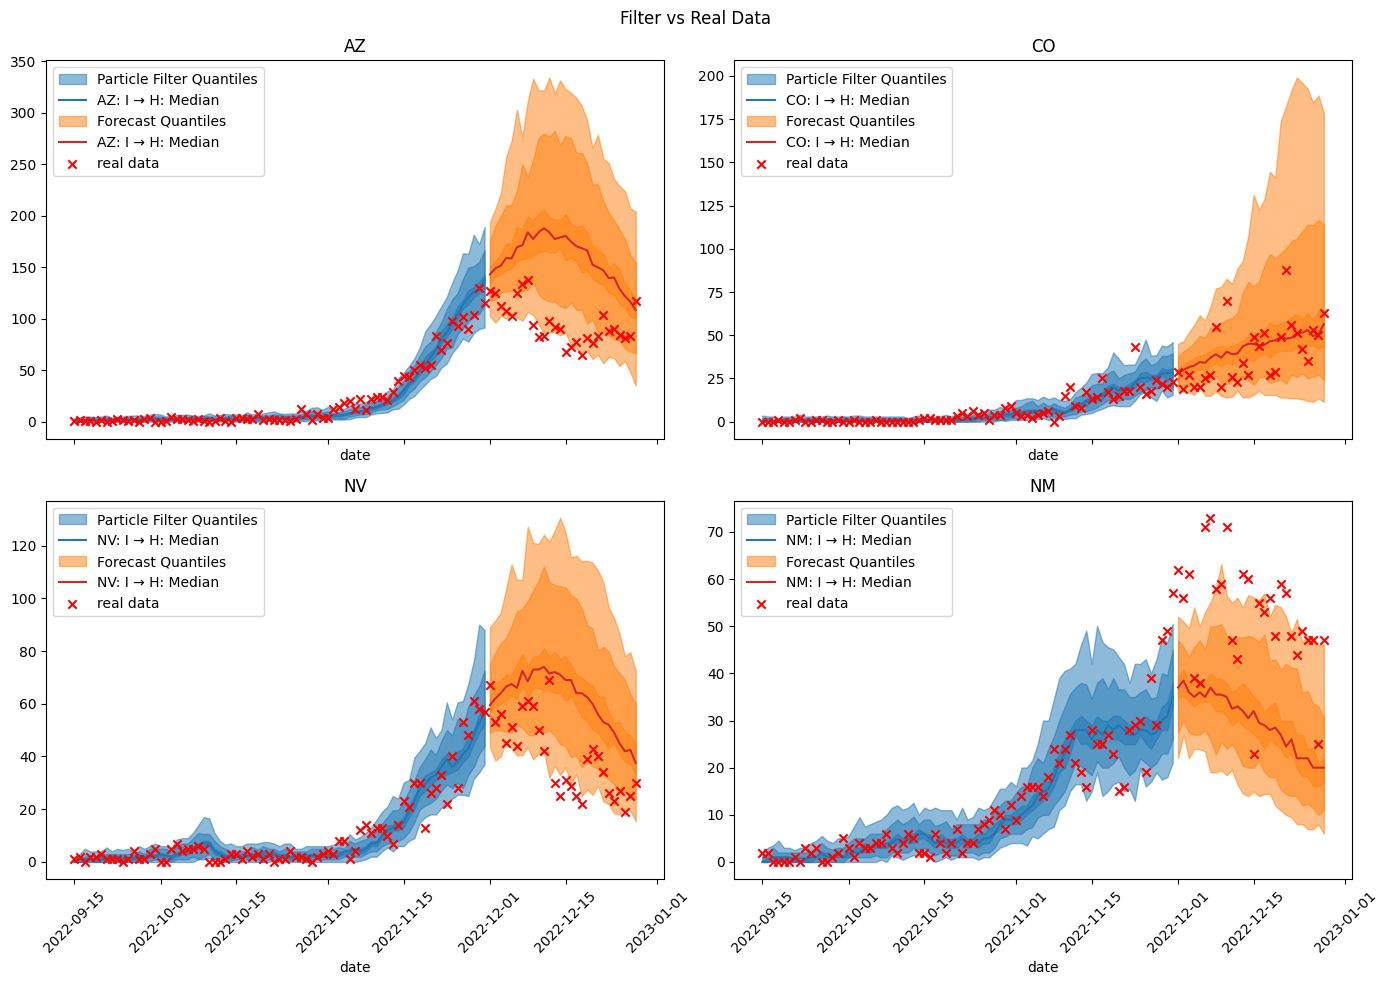

In [34]:
from math import ceil

from epymorph.forecasting.filter_plot import PlotRendererPipeline

tf = TimeFrame.of(rume.time_frame.start_date, 7 * cutoff_week + extend_duration)


real_data_result = adrio.with_context(scope=rume.scope, time_frame=tf).inspect().result
real_data = real_data_result["value"]

plotter_pf = PlotRendererPipeline(particle_filter_output)
plotter_forecast = PlotRendererPipeline(forecast_output)
geo = observations.model_link.geo
quantity = observations.model_link.quantity
time = observations.model_link.time
realization = particle_filter_output.select.all()
data_date_range = np.arange(0, tf.days, 1)

ncols = 2
nrows = ceil(geo.scope.nodes / ncols)
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(ncols * 7, nrows * 5),
    sharex=True,
    layout="compressed",
)

fig.suptitle("Filter vs Real Data")

for index, ax in enumerate(axes.ravel()):
    state = rume.scope.labels[index]
    geo = rume.scope.select.by_state(state)
    plotter_pf.quantiles_plt(
        ax,
        geo,
        time,
        quantity,
        legend="on",
        kwarg_type="geo",
        time_format="date",
        label_format="Particle Filter Quantiles",
        fill_kwargs=[{"color": "tab:blue", "alpha": 0.5}],
        line_kwargs=[{"color": "tab:blue"}],
        credible_intervals=[95, 75, 25],
    )
    plotter_forecast.quantiles_plt(
        ax,
        geo,
        time,
        quantity,
        legend="on",
        kwarg_type="geo",
        time_format="date",
        label_format="Forecast Quantiles",
        fill_kwargs=[{"color": "tab:orange", "alpha": 0.5}],
        line_kwargs=[{"color": "tab:red"}],
        credible_intervals=[95, 75, 25],
    )

    ax.scatter(
        tf.to_date_range(),
        real_data[:, index],
        marker="x",
        color="red",
        label="real data",
        zorder=100,
    )

    ax.set_title(f"{state}")
    ax.legend()

fig.tight_layout()
plt.show()


![](img/G3-fct/forecast.png)

We can layer the particle filter and forecast to incorporate new data points. Let's examine how the particle filter performs when we incorporate the next week's data and forecast another four weeks ahead. 

In [35]:
extend_pf = 7  # Extend the filter by 7 days
particle_filter_simulator = ParticleFilterSimulator(
    config=PipelineConfig.from_output(particle_filter_output, extend_pf),
    observations=observations,
)

In [36]:
with pipeline_messaging(): 
    particle_filter_output_update = particle_filter_simulator.run(rng=rng)

Loading epymorph.adrio.acs5.Population:
  |####################| 100%  (1.065s)
Loading epymorph.adrio.cdc.InfluenzaStateHospitalizationDaily:
  |####################| 100%  (0.573s)
Running simulation (ParticleFilterSimulator):
• 2022-12-01 to 2022-12-07 (7 days)
• 4 geo nodes
• 100 realizations
  |####################| 100%                     
Runtime: 5.317s


- [ ] Rerun the forecast with the updated particle filter output. A key advantage of the particle filter is the online nature of the algorithm. To refine our particle filter estimate we need only start from the final output of the previous run. 

In [37]:
forecast_simulator = ForecastSimulator(
    PipelineConfig.from_output(particle_filter_output_update, extend_duration)
)

In [38]:
with pipeline_messaging():
    forecast_output_update = forecast_simulator.run(rng=rng)

Loading epymorph.adrio.acs5.Population:
  |####################| 100%  (1.201s)
Running simulation (ForecastSimulator):
• 2022-12-08 to 2023-01-04 (28 days)
• 4 geo nodes
• 100 realizations
  |####################| 100%                     
Runtime: 1.835s


/tmp/ipykernel_9334/854073665.py:87: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


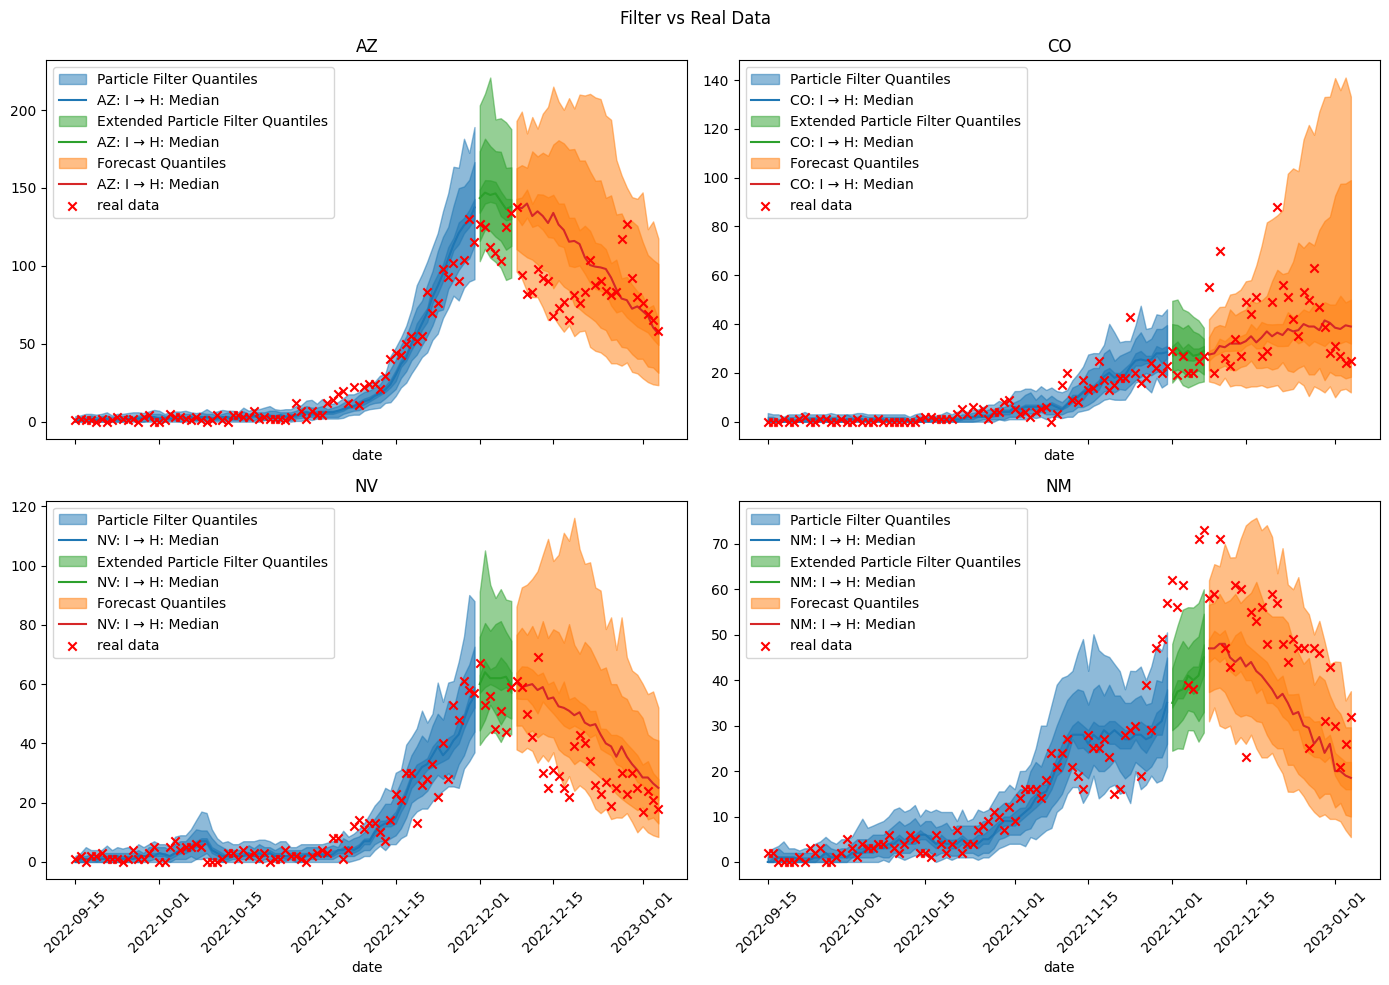

In [39]:
from math import ceil

from epymorph.forecasting.filter_plot import PlotRendererPipeline


tf = TimeFrame.of(
    rume.time_frame.start_date, 7 * cutoff_week + extend_pf + extend_duration
)
real_data_result = adrio.with_context(scope=rume.scope, time_frame=tf).inspect().result
real_data = real_data_result["value"]

plotter_pf_update = PlotRendererPipeline(particle_filter_output_update)
plotter_forecast_update = PlotRendererPipeline(forecast_output_update)
geo = observations.model_link.geo
quantity = observations.model_link.quantity
time = observations.model_link.time
realization = particle_filter_output.select.all()
data_date_range = np.arange(0, tf.days, 1)

ncols = 2
nrows = ceil(geo.scope.nodes / ncols)
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(ncols * 7, nrows * 5),
    sharex=True,
    layout="compressed",
)

fig.suptitle("Filter vs Real Data")

for index, ax in enumerate(axes.ravel()):
    state = rume.scope.labels[index]
    geo = rume.scope.select.by_state(state)
    plotter_pf.quantiles_plt(
        ax,
        geo,
        time,
        quantity,
        legend="on",
        kwarg_type="geo",
        time_format="date",
        label_format="Particle Filter Quantiles",
        fill_kwargs=[{"color": "tab:blue", "alpha": 0.5}],
        line_kwargs=[{"color": "tab:blue"}],
        credible_intervals=[95, 75, 25],
    )
    plotter_pf_update.quantiles_plt(
        ax,
        geo,
        time,
        quantity,
        legend="on",
        kwarg_type="geo",
        time_format="date",
        label_format="Extended Particle Filter Quantiles",
        fill_kwargs=[{"color": "tab:green", "alpha": 0.5}],
        line_kwargs=[{"color": "tab:green"}],
        credible_intervals=[95, 75, 25],
    )
    plotter_forecast_update.quantiles_plt(
        ax,
        geo,
        time,
        quantity,
        legend="on",
        kwarg_type="geo",
        time_format="date",
        label_format="Forecast Quantiles",
        fill_kwargs=[{"color": "tab:orange", "alpha": 0.5}],
        line_kwargs=[{"color": "tab:red"}],
        credible_intervals=[95, 75, 25],
    )

    ax.scatter(
        tf.to_date_range(),
        real_data[:, index],
        marker="x",
        color="red",
        label="real data",
        zorder=100,
    )

    ax.set_title(f"{state}")
    ax.legend()

fig.tight_layout()
plt.show()


![](img/G3-fct/forecast_extension.png)

## Notes

We see a narrowing of the forecast uncertainty as more data is assimilated by the filter. The downwards trajectory of hospitalizations is captured in 3 of the 4 states. Colorado's hospitalizations admissions exhibit sub-exponential growth which proves a challenge for this model. 
